<a href="https://colab.research.google.com/github/BrianLearning-source/PCVK_Genap_2026/blob/main/week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WEEK 3**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 20


/tmp/ipykernel_4631/1345043567.py:14: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


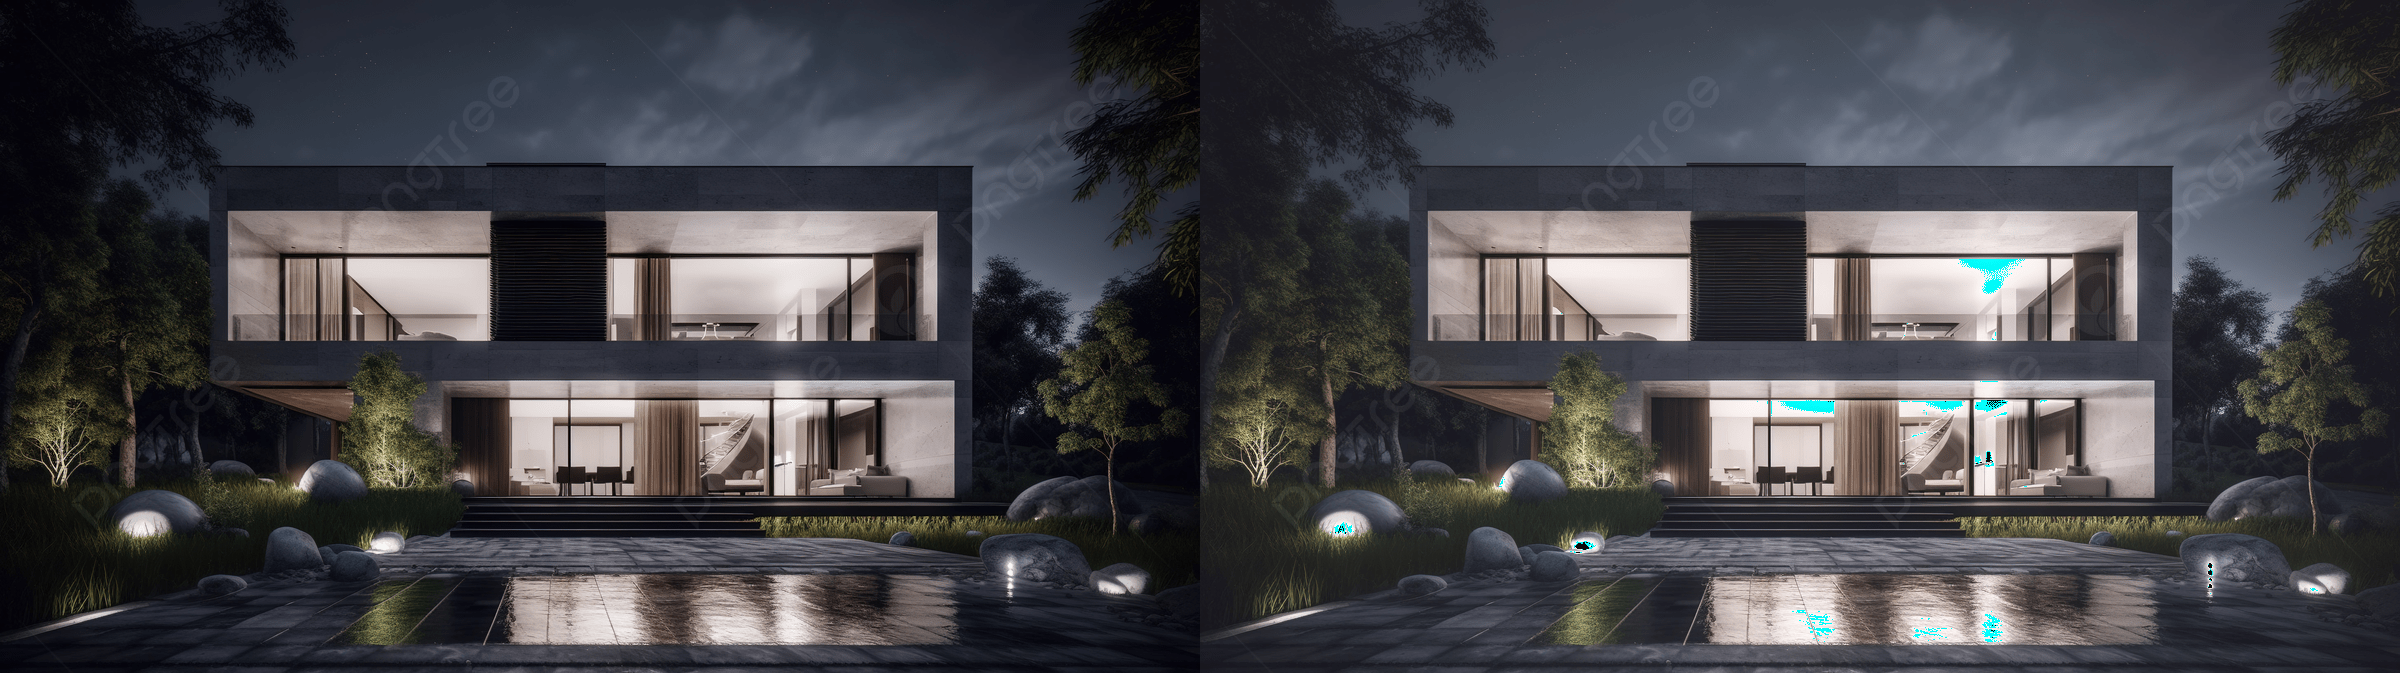

In [6]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/modern_house.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang
terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

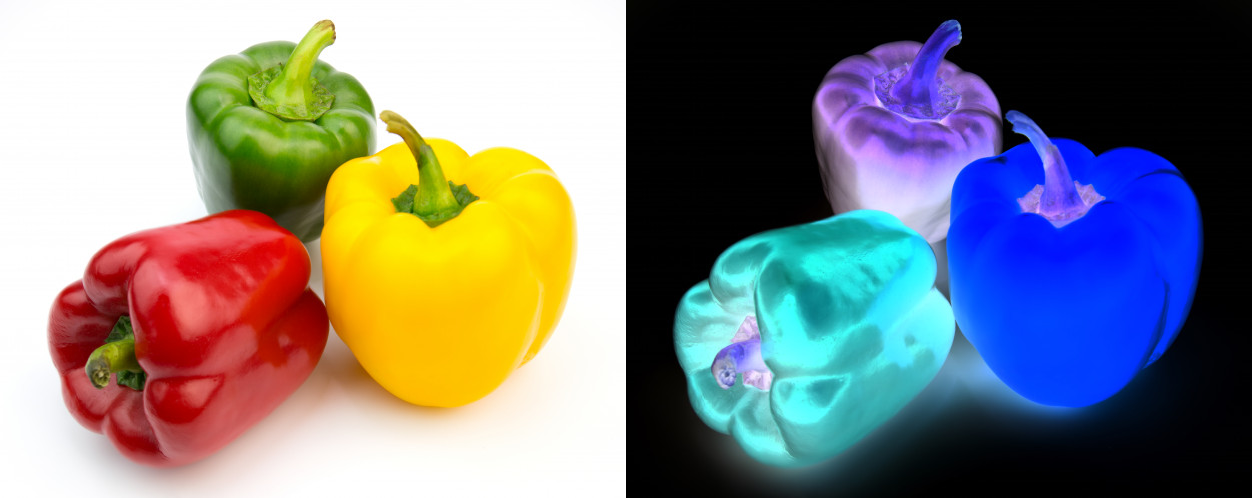

In [7]:
original  = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
orignal = 255 - original

final_frame = cv.hconcat((original, orignal))
cv2_imshow(final_frame)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


/tmp/ipykernel_4631/3712996511.py:28: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


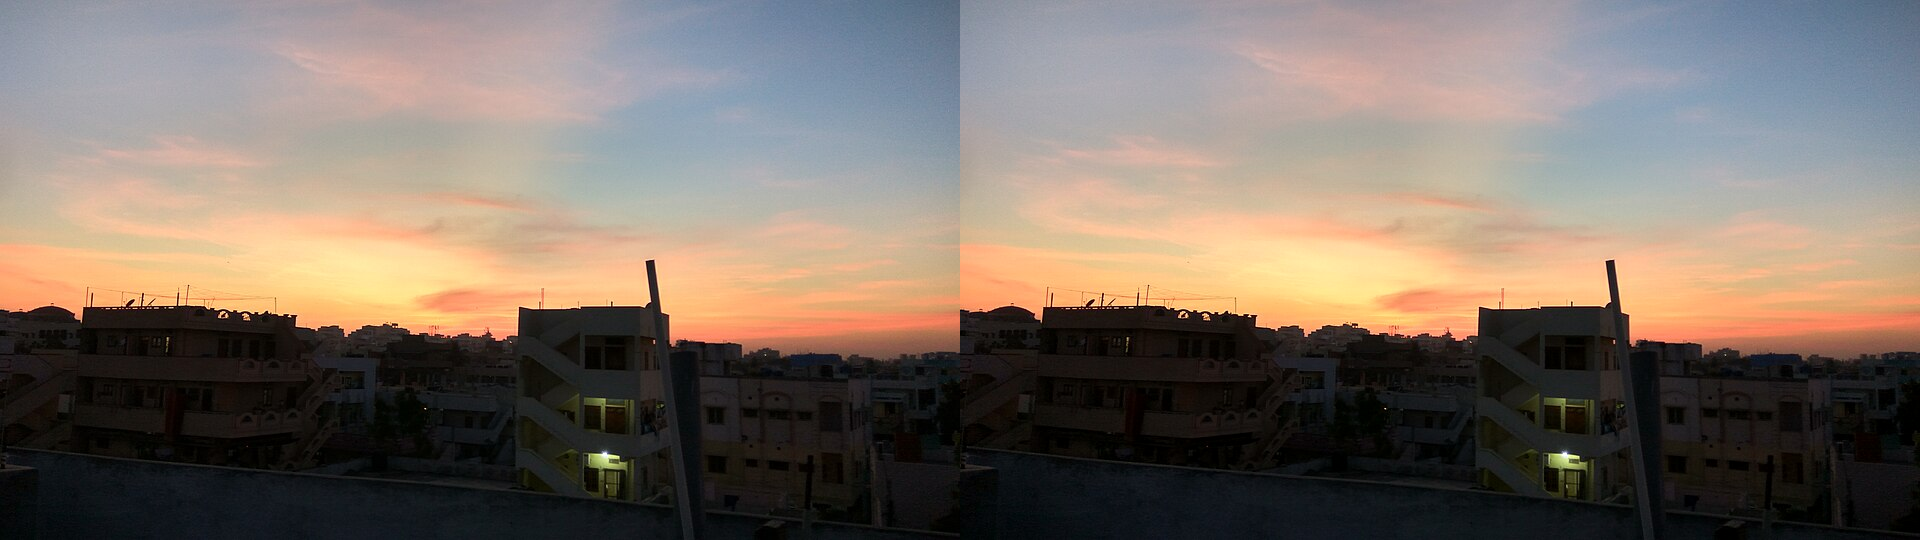

In [17]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')

try:
  brightness = int(input('Masukkan tingkat kecerahan: '))
except ValueError:
  print('Error, not a number')

try:
  contras = float(input('Masukkan kontras: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/sunset.jpg')

def truncate(value):
    if value < 0:
        return 0
    elif value > 255:
        return 255
    return int(value)

brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

factor = (259 * (contras + 255)) / (255 * (259 - contras))

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b = float(original[y, x, 0])
        g = float(original[y, x, 1])
        r = float(original[y, x, 2])

        redBaru = truncate(factor * (r - 128) + 128 )
        greenBaru = truncate(factor * (g - 128) + 128 )
        blueBaru = truncate(factor * (b - 128) + 128 )

        brightness_image[y, x, 0] = blueBaru
        brightness_image[y, x, 1] = greenBaru
        brightness_image[y, x, 2] = redBaru

hasil_gabung = np.hstack((original, brightness_image))
cv2_imshow(hasil_gabung)